## Part-1 - Load & Explore

In [1]:
# Importing the libraries and load the CSV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("D:\Audit\Python\Homework_3\Homework_3\invoices_bd.csv")

In [2]:
# Display the data
display(df.head(5))
display(df.tail(5))

,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
0,INV-1072,Ayesha Textiles,01-Jan-26,02-Mar-26,75000,0.0,Unpaid,NaN,Cosmetics,Sylhet
1,INV-1025,Ayesha Textiles,07-Apr-26,07-May-26,75000,NaN,Unpaid,NaN,Cosmetics,Sylhet
2,INV-1052,Hasan Electronics,08-Feb-26,09-Apr-26,20000,NaN,Unpaid,NaN,Food,Rajshahi
3,INV-1163,Fatima Enterprises,20-Feb-26,06-Apr-26,75000,26100.0,Partial,4/28/2026,Food,Chittagong
4,INV-1098,Bilkis Garments,15-Jan-26,01-Mar-26,100000,100000.0,Paid,2/16/2026,Pharma,Chittagong


,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
200,INV-1069,Tahmina Logistics,04-Feb-26,05-Apr-26,25000,0.0,Unpaid,NaN,Food,Dhaka
201,INV-1169,rahim trading ltd,05-Jan-26,04-Feb-26,20000,20000.0,Paid,1/23/2026,IT Services,Dhaka
202,INV-1186,Rahim Trading Ltd,10-Feb-26,12-Mar-26,15000,0.0,Unpaid,NaN,Textiles,Dhaka
203,INV-1036,Ayesha Textiles,05-Dec-25,19-Jan-26,15000,5100.0,Partial,1/26/2026,Textiles,Sylhet
204,INV-1130,Tahmina Logistics,29-Jan-26,30-Mar-26,25000,25000.0,Paid,3/28/2026,Hardware,dhaka


In [3]:
# Explore the data: Statistical Analysis of the datasets
display(f"The total number of rows and columns: {df.shape}") 
display(f"The name of the columns in the datasets: {df.columns}") 
display(f"The data types {df.info()}")
df.describe() 

'The total number of rows and columns: (205, 10)'

"The name of the columns in the datasets: Index(['invoice_id', 'customer_name', 'invoice_date', 'due_date', 'amount_bdt',\n       'paid_amount_bdt', 'status', 'payment_date', 'category', 'city'],\n      dtype='object')"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   invoice_id       205 non-null    object 
 1   customer_name    203 non-null    object 
 2   invoice_date     205 non-null    object 
 3   due_date         205 non-null    object 
 4   amount_bdt       205 non-null    object 
 5   paid_amount_bdt  180 non-null    float64
 6   status           205 non-null    object 
 7   payment_date     110 non-null    object 
 8   category         205 non-null    object 
 9   city             205 non-null    object 
dtypes: float64(1), object(9)
memory usage: 16.1+ KB


'The data types None'

,paid_amount_bdt
count,180.000000
mean,23182.777778
std,29387.997456
min,0.000000
25%,0.000000
50%,10350.000000
75%,40550.000000
max,100000.000000


In [4]:
# Statistical Analysis of the datasets:
# df.describe() 
# df.describe(include='all')

#### How many invoices are in the dataset? ####
There are 205 invoices in the datasets. 
#### What data types need fixing? ####
The date columns (invoice_date, due_date, payment_date) and the amount_bdt column are currently stored as objects (strings). These need to be converted to datetime and float formats, respectively, for proper analysis. 
#### Are there any null values? ####
Yes, there are missing values in the customer_name, paid_amount_bdt, and payment_date columns. Given there are 205 invoices, the customer_name column should be fully populated, but it currently contains gaps.

## Part-2 - Data Cleaning ##

##### Handling Missing values #####

In [5]:
print("Missing values per column:")
display(df.isna().sum())
display(f"Total number of missing values: {df.isna().sum().sum()}")


Missing values per column:


invoice_id          0
customer_name       2
invoice_date        0
due_date            0
amount_bdt          0
paid_amount_bdt    25
status              0
payment_date       95
category            0
city                0
dtype: int64

'Total number of missing values: 122'

In [6]:
# Check nulls with
df[df.isnull().any(axis=1)].head()

,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
0,INV-1072,Ayesha Textiles,01-Jan-26,02-Mar-26,75000,0.0,Unpaid,NaN,Cosmetics,Sylhet
1,INV-1025,Ayesha Textiles,07-Apr-26,07-May-26,75000,NaN,Unpaid,NaN,Cosmetics,Sylhet
2,INV-1052,Hasan Electronics,08-Feb-26,09-Apr-26,20000,NaN,Unpaid,NaN,Food,Rajshahi
8,INV-1143,Karim & Sons,13-Jan-26,12-Feb-26,75000,0.0,Unpaid,NaN,Textiles,Dhaka
9,INV-1132,Sultana Pharma,10-Dec-25,08-Feb-26,50000,NaN,Unpaid,NaN,Hardware,Sylhet


In [7]:
df_customer_nulls = df[df["customer_name"].isna()]
display(df_customer_nulls)

,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
150,INV-1156,NaN,10-Mar-26,09-May-26,25000,NaN,Unpaid,NaN,Electronics,Sylhet
157,INV-1078,NaN,25-Mar-26,09-May-26,20000,20000.0,Paid,4/28/2026,Cosmetics,Chittagong


#### Two records have missing values in the customer name column. I will not drop these rows because one of those customers has not paid yet; therefore, it is important to keep this data for tracking purposes. ####


In [8]:
df_paid_nulls = df[df["paid_amount_bdt"].isna()].reset_index(drop=True)
display(df_paid_nulls.head())

,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
0,INV-1025,Ayesha Textiles,07-Apr-26,07-May-26,75000,NaN,Unpaid,NaN,Cosmetics,Sylhet
1,INV-1052,Hasan Electronics,08-Feb-26,09-Apr-26,20000,NaN,Unpaid,NaN,Food,Rajshahi
2,INV-1132,Sultana Pharma,10-Dec-25,08-Feb-26,50000,NaN,Unpaid,NaN,Hardware,Sylhet
3,INV-1151,Jamal Construction,13-Mar-26,12-Apr-26,50000,NaN,Unpaid,NaN,Hardware,Chittagong
4,INV-1054,Rahim Trading Ltd,21-Apr-26,05-Jun-26,15000,NaN,Unpaid,NaN,Cosmetics,Dhaka


In [9]:
# Replacing the Null value of 'paid_amount_bdt' to 0 :
df["paid_amount_bdt"] = df["paid_amount_bdt"].fillna(0)
display(df.head())

,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
0,INV-1072,Ayesha Textiles,01-Jan-26,02-Mar-26,75000,0.0,Unpaid,NaN,Cosmetics,Sylhet
1,INV-1025,Ayesha Textiles,07-Apr-26,07-May-26,75000,0.0,Unpaid,NaN,Cosmetics,Sylhet
2,INV-1052,Hasan Electronics,08-Feb-26,09-Apr-26,20000,0.0,Unpaid,NaN,Food,Rajshahi
3,INV-1163,Fatima Enterprises,20-Feb-26,06-Apr-26,75000,26100.0,Partial,4/28/2026,Food,Chittagong
4,INV-1098,Bilkis Garments,15-Jan-26,01-Mar-26,100000,100000.0,Paid,2/16/2026,Pharma,Chittagong


In [10]:
# paid_amount_bdt_nulls = df["paid_amount_bdt"].isna().sum()
# display(paid_amount_bdt_nulls)

#### I have converted all NaN values to 0. I observed that the Status column for these records is marked as 'unpaid' and there is no payment_date information; therefore, I assumed a payment amount of 0. ####

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   invoice_id       205 non-null    object 
 1   customer_name    203 non-null    object 
 2   invoice_date     205 non-null    object 
 3   due_date         205 non-null    object 
 4   amount_bdt       205 non-null    object 
 5   paid_amount_bdt  205 non-null    float64
 6   status           205 non-null    object 
 7   payment_date     110 non-null    object 
 8   category         205 non-null    object 
 9   city             205 non-null    object 
dtypes: float64(1), object(9)
memory usage: 16.1+ KB


##### Remove Duplicates:

In [12]:
print("The duplicate values in invoice_id column: ")
# display(df["invoice_id"].duplicated().sum())
display(df[df["invoice_id"].duplicated(keep=False)].sort_values(by='invoice_id',ascending=True).reset_index(drop=True))

The duplicate values in invoice_id column: 


,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
0,INV-1016,Karim & Sons,13-Feb-26,15-Mar-26,"50,000",0.0,Unpaid,NaN,Hardware,Dhaka
1,INV-1016,Karim & Sons,13-Feb-26,15-Mar-26,20000,0.0,Unpaid,NaN,Hardware,Dhaka
2,INV-1031,Ayesha Textiles,04-Apr-26,04-May-26,30000,30000.0,Paid,5/2/2026,Food,Sylhet
3,INV-1031,Ayesha Textiles,04-Apr-26,04-May-26,30000,30000.0,Paid,5/2/2026,Food,Sylhet
4,INV-1096,Bilkis Garments,25-Feb-26,11-Apr-26,100000,100000.0,Paid,4/5/2026,Construction,Chittagong
5,INV-1096,Bilkis Garments,25-Feb-26,11-Apr-26,100000,100000.0,Paid,4/5/2026,Construction,Chittagong
6,INV-1129,Hasan Electronics,14-Dec-25,12-Feb-26,50000,25000.0,Partial,3/12/2026,Auto Parts,Rajshahi
7,INV-1129,Hasan Electronics,14-Dec-25,12-Feb-26,50000,25000.0,Partial,3/12/2026,Auto Parts,Rajshahi
8,INV-1159,Omar Food Products,19-Feb-26,05-Apr-26,75000,75000.0,Paid,3/27/2026,Food,Rajshahi
9,INV-1159,Omar Food Products,19-Feb-26,05-Apr-26,75000,75000.0,Paid,3/27/2026,Food,Rajshahi


In [13]:
# Check Count of each invoice_id
print("Get the counts for every duplicate invoice_id")
values_count = df["invoice_id"].value_counts()
duplicates = values_count[values_count > 1]
display(duplicates)
display(f"Total duplicate rows: {duplicates.sum()}")

Get the counts for every duplicate invoice_id


invoice_id
INV-1159    2
INV-1016    2
INV-1031    2
INV-1096    2
INV-1129    2
Name: count, dtype: int64

'Total duplicate rows: 10'

In [14]:
cleaned_df = df.drop_duplicates(subset=['invoice_id'], keep='first')
display(cleaned_df.head())

,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
0,INV-1072,Ayesha Textiles,01-Jan-26,02-Mar-26,75000,0.0,Unpaid,NaN,Cosmetics,Sylhet
1,INV-1025,Ayesha Textiles,07-Apr-26,07-May-26,75000,0.0,Unpaid,NaN,Cosmetics,Sylhet
2,INV-1052,Hasan Electronics,08-Feb-26,09-Apr-26,20000,0.0,Unpaid,NaN,Food,Rajshahi
3,INV-1163,Fatima Enterprises,20-Feb-26,06-Apr-26,75000,26100.0,Partial,4/28/2026,Food,Chittagong
4,INV-1098,Bilkis Garments,15-Jan-26,01-Mar-26,100000,100000.0,Paid,2/16/2026,Pharma,Chittagong


In [15]:
cleaned_df["invoice_id"].duplicated().sum()

np.int64(0)

In [16]:
display(cleaned_df[cleaned_df['invoice_id'] == 'INV-1016']) ## to show first occurance keept 

,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
72,INV-1016,Karim & Sons,13-Feb-26,15-Mar-26,"50,000",0.0,Unpaid,NaN,Hardware,Dhaka


##### I cleaned the duplicate invoice_ids using a subset because I noticed that invoice_id 'INV-1016' appeared twice with different values (50,000 and 20,000). I intentionally used the keep='first' argument to preserve the original 50,000 value and remove the discrepancy. #####

In [17]:
# cleaned_df.columns

##### Fix the Data Types

In [18]:
cols = df.copy()
cols = ['invoice_date','due_date','payment_date']

for col in cols:
    df[cols] = df[cols].apply(pd.to_datetime, errors='coerce')
display(df[cols].head())

C:\Users\Ligion\AppData\Local\Temp\ipykernel_11796\2825728997.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[cols] = df[cols].apply(pd.to_datetime, errors='coerce')
C:\Users\Ligion\AppData\Local\Temp\ipykernel_11796\2825728997.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[cols] = df[cols].apply(pd.to_datetime, errors='coerce')


,invoice_date,due_date,payment_date
0,2026-01-01,2026-03-02,NaT
1,2026-04-07,2026-05-07,NaT
2,2026-02-08,2026-04-09,NaT
3,2026-02-20,2026-04-06,2026-04-28
4,2026-01-15,2026-03-01,2026-02-16


In [19]:
cleaned_df.loc[:, cols] = df[cols]
display(cleaned_df.head())

,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
0,INV-1072,Ayesha Textiles,2026-01-01 00:00:00,2026-03-02 00:00:00,75000,0.0,Unpaid,NaT,Cosmetics,Sylhet
1,INV-1025,Ayesha Textiles,2026-04-07 00:00:00,2026-05-07 00:00:00,75000,0.0,Unpaid,NaT,Cosmetics,Sylhet
2,INV-1052,Hasan Electronics,2026-02-08 00:00:00,2026-04-09 00:00:00,20000,0.0,Unpaid,NaT,Food,Rajshahi
3,INV-1163,Fatima Enterprises,2026-02-20 00:00:00,2026-04-06 00:00:00,75000,26100.0,Partial,2026-04-28 00:00:00,Food,Chittagong
4,INV-1098,Bilkis Garments,2026-01-15 00:00:00,2026-03-01 00:00:00,100000,100000.0,Paid,2026-02-16 00:00:00,Pharma,Chittagong


In [20]:
cleaned_df['amount_bdt'] = pd.to_numeric(cleaned_df['amount_bdt'],errors='coerce')
display(cleaned_df.head())

C:\Users\Ligion\AppData\Local\Temp\ipykernel_11796\1097029174.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['amount_bdt'] = pd.to_numeric(cleaned_df['amount_bdt'],errors='coerce')


,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
0,INV-1072,Ayesha Textiles,2026-01-01 00:00:00,2026-03-02 00:00:00,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet
1,INV-1025,Ayesha Textiles,2026-04-07 00:00:00,2026-05-07 00:00:00,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet
2,INV-1052,Hasan Electronics,2026-02-08 00:00:00,2026-04-09 00:00:00,20000.0,0.0,Unpaid,NaT,Food,Rajshahi
3,INV-1163,Fatima Enterprises,2026-02-20 00:00:00,2026-04-06 00:00:00,75000.0,26100.0,Partial,2026-04-28 00:00:00,Food,Chittagong
4,INV-1098,Bilkis Garments,2026-01-15 00:00:00,2026-03-01 00:00:00,100000.0,100000.0,Paid,2026-02-16 00:00:00,Pharma,Chittagong


In [21]:
cleaned_df.dtypes #verifying the data types

invoice_id          object
customer_name       object
invoice_date        object
due_date            object
amount_bdt         float64
paid_amount_bdt    float64
status              object
payment_date        object
category            object
city                object
dtype: object

##### Standardize strings

In [22]:
cleaned_df['customer_name'] = cleaned_df['customer_name'].str.strip().str.title()
display(cleaned_df.head())

C:\Users\Ligion\AppData\Local\Temp\ipykernel_11796\1225395952.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['customer_name'] = cleaned_df['customer_name'].str.strip().str.title()


,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
0,INV-1072,Ayesha Textiles,2026-01-01 00:00:00,2026-03-02 00:00:00,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet
1,INV-1025,Ayesha Textiles,2026-04-07 00:00:00,2026-05-07 00:00:00,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet
2,INV-1052,Hasan Electronics,2026-02-08 00:00:00,2026-04-09 00:00:00,20000.0,0.0,Unpaid,NaT,Food,Rajshahi
3,INV-1163,Fatima Enterprises,2026-02-20 00:00:00,2026-04-06 00:00:00,75000.0,26100.0,Partial,2026-04-28 00:00:00,Food,Chittagong
4,INV-1098,Bilkis Garments,2026-01-15 00:00:00,2026-03-01 00:00:00,100000.0,100000.0,Paid,2026-02-16 00:00:00,Pharma,Chittagong


In [23]:
# verifying there was any space gap: 
space_diff = cleaned_df['customer_name'].str.len() - cleaned_df['customer_name'].str.strip().str.len()
display(space_diff.max())                              

0.0

##### I initially looked at the unique values in my dataset and noticed a typo: 'dhaka' (lowercase) and 'Dhaka' (capitalized). To maintain consistency, I replaced 'dhaka' with 'Dhaka'. #####

In [24]:
#check unique value:

cleaned_df['city'].unique()

array(['Sylhet', 'Rajshahi', 'Chittagong', 'Dhaka', ' Chittagong ',
       'dhaka'], dtype=object)

##### Check unique value and replace the value of 'dhaka' to 'Dhaka':

In [25]:
cleaned_df['city'] = cleaned_df['city'].replace('dhaka','Dhaka').str.strip()
cleaned_df['city'].unique()

C:\Users\Ligion\AppData\Local\Temp\ipykernel_11796\4221516424.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['city'] = cleaned_df['city'].replace('dhaka','Dhaka').str.strip()


array(['Sylhet', 'Rajshahi', 'Chittagong', 'Dhaka'], dtype=object)

## Part -3 : Build the Aging Report


In [26]:
# Filter Unpaid Invoices
# filtered_status = cleaned_df[(cleaned_df['status'] == 'Unpaid') | (cleaned_df['status'] == 'Partial')]
df_outstanding = cleaned_df[cleaned_df['status'].isin(['Unpaid','Partial'])]
display(df_outstanding.head(3))


,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
0,INV-1072,Ayesha Textiles,2026-01-01 00:00:00,2026-03-02 00:00:00,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet
1,INV-1025,Ayesha Textiles,2026-04-07 00:00:00,2026-05-07 00:00:00,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet
2,INV-1052,Hasan Electronics,2026-02-08 00:00:00,2026-04-09 00:00:00,20000.0,0.0,Unpaid,NaT,Food,Rajshahi


##### Calculate the outstanding Balances:

In [27]:
print("How many outstanding invoices exists: ")
outstanding_count = cleaned_df.groupby('status')['status'].count()
display(outstanding_count)

How many outstanding invoices exists: 


status
Paid       76
Partial    30
Unpaid     94
Name: status, dtype: int64

##### Calculate Outstanding Balance: 

In [28]:

cleaned_df['paid_amount_bdt'] = cleaned_df['paid_amount_bdt'].fillna(0)

amount_sum =  cleaned_df['amount_bdt']
paid_amount_sum =  cleaned_df['paid_amount_bdt']

df_outstanding['outstanding_bdt'] = amount_sum - paid_amount_sum
display(df_outstanding.head())

C:\Users\Ligion\AppData\Local\Temp\ipykernel_11796\1250024162.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['paid_amount_bdt'] = cleaned_df['paid_amount_bdt'].fillna(0)
C:\Users\Ligion\AppData\Local\Temp\ipykernel_11796\1250024162.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_outstanding['outstanding_bdt'] = amount_sum - paid_amount_sum


,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city,outstanding_bdt
0,INV-1072,Ayesha Textiles,2026-01-01 00:00:00,2026-03-02 00:00:00,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet,75000.0
1,INV-1025,Ayesha Textiles,2026-04-07 00:00:00,2026-05-07 00:00:00,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet,75000.0
2,INV-1052,Hasan Electronics,2026-02-08 00:00:00,2026-04-09 00:00:00,20000.0,0.0,Unpaid,NaT,Food,Rajshahi,20000.0
3,INV-1163,Fatima Enterprises,2026-02-20 00:00:00,2026-04-06 00:00:00,75000.0,26100.0,Partial,2026-04-28 00:00:00,Food,Chittagong,48900.0
7,INV-1085,Tahmina Logistics,2026-02-26 00:00:00,2026-03-28 00:00:00,45000.0,21200.0,Partial,2026-04-10 00:00:00,Electronics,Dhaka,23800.0


In [29]:
# Calculating Overdue :
df_outstanding['due_date'] = pd.to_datetime(
    df_outstanding['due_date'],
    errors='coerce'
)

today = pd.Timestamp.today().normalize()

df_outstanding['days_overdue'] = (
    today - df_outstanding['due_date']
).dt.days.clip(lower=0)

C:\Users\Ligion\AppData\Local\Temp\ipykernel_11796\1833750825.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_outstanding['due_date'] = pd.to_datetime(
C:\Users\Ligion\AppData\Local\Temp\ipykernel_11796\1833750825.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_outstanding['days_overdue'] = (


In [30]:
display(df_outstanding.describe())

,due_date,amount_bdt,paid_amount_bdt,outstanding_bdt,days_overdue
count,124,122.000000,124.000000,122.000000,124.000000
mean,2026-03-20 17:48:23.225806336,43442.622951,4499.193548,38869.672131,52.491935
min,2025-12-27 00:00:00,5000.000000,0.000000,2000.000000,0.000000
25%,2026-02-16 06:00:00,15000.000000,0.000000,15000.000000,12.000000
50%,2026-03-19 00:00:00,45000.000000,0.000000,30000.000000,52.000000
75%,2026-04-28 00:00:00,75000.000000,0.000000,60000.000000,82.750000
max,2026-06-20 00:00:00,100000.000000,52100.000000,100000.000000,134.000000
std,NaN,30172.246341,11097.663242,28922.906617,40.841055


##### Create Aging Buckets:

In [31]:
def aging_bucket(x):
    if x >= 91:
        return '90+ Days'
    elif x >= 61:
        return '61-90 Days'
    elif x >= 31:
        return '31-60 Days'
    else :
        return 'Current'

# Apply the  function
df_outstanding["aging_bucket"] = df_outstanding["days_overdue"].apply(aging_bucket)
display(df_outstanding.head())

C:\Users\Ligion\AppData\Local\Temp\ipykernel_11796\3745583835.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_outstanding["aging_bucket"] = df_outstanding["days_overdue"].apply(aging_bucket)


,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city,outstanding_bdt,days_overdue,aging_bucket
0,INV-1072,Ayesha Textiles,2026-01-01 00:00:00,2026-03-02,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet,75000.0,69,61-90 Days
1,INV-1025,Ayesha Textiles,2026-04-07 00:00:00,2026-05-07,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet,75000.0,3,Current
2,INV-1052,Hasan Electronics,2026-02-08 00:00:00,2026-04-09,20000.0,0.0,Unpaid,NaT,Food,Rajshahi,20000.0,31,31-60 Days
3,INV-1163,Fatima Enterprises,2026-02-20 00:00:00,2026-04-06,75000.0,26100.0,Partial,2026-04-28 00:00:00,Food,Chittagong,48900.0,34,31-60 Days
7,INV-1085,Tahmina Logistics,2026-02-26 00:00:00,2026-03-28,45000.0,21200.0,Partial,2026-04-10 00:00:00,Electronics,Dhaka,23800.0,43,31-60 Days


In [32]:
# Strip whitespace and convert to lowercase to be sure
df_outstanding.columns = df_outstanding.columns.str.strip().str.lower()

##### Pivot the Aging report

In [33]:
aging_report = df_outstanding.pivot_table(index="customer_name",
                           columns="aging_bucket",
                           values="outstanding_bdt",
                           aggfunc='sum',
                           fill_value= 0,
                           )
aging_report['Total'] = aging_report.sum(axis=1)
aging_report = aging_report.sort_values(by= "Total",
                                        ascending=False)
display(aging_report)


aging_bucket,31-60 Days,61-90 Days,90+ Days,Current,Total
customer_name,,,,,
Fatima Enterprises,155100.0,150000.0,155000.0,145000.0,605100.0
Rafiq Auto Parts,125000.0,75000.0,113300.0,245000.0,558300.0
Jamal Construction,262800.0,100000.0,70500.0,110000.0,543300.0
Bilkis Garments,75000.0,3200.0,196700.0,174300.0,449200.0
Tahmina Logistics,213800.0,50000.0,0.0,125000.0,388800.0
Ayesha Textiles,15000.0,156200.0,109900.0,90000.0,371100.0
Rahim Trading Ltd,15000.0,161200.0,4000.0,175000.0,355200.0
Nusrat Imports,25000.0,55000.0,155000.0,60000.0,295000.0
Karim & Sons,0.0,95000.0,0.0,132100.0,227100.0


## Part-4 : Analysis & Export

In [34]:
display(df_outstanding.head(3))

,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city,outstanding_bdt,days_overdue,aging_bucket
0,INV-1072,Ayesha Textiles,2026-01-01 00:00:00,2026-03-02,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet,75000.0,69,61-90 Days
1,INV-1025,Ayesha Textiles,2026-04-07 00:00:00,2026-05-07,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet,75000.0,3,Current
2,INV-1052,Hasan Electronics,2026-02-08 00:00:00,2026-04-09,20000.0,0.0,Unpaid,NaT,Food,Rajshahi,20000.0,31,31-60 Days


In [35]:
# Summary Statistics:
print('Total outstanding amount across all customers:')
df_outstanding_customer = df_outstanding['outstanding_bdt'].sum()
print(df_outstanding_customer,'\n')

print('The Avg. outstanding amount per customers:')
df_outstanding_customer =  df_outstanding.groupby('customer_name')['outstanding_bdt'].mean().reset_index(name='Avg. outstanding')
df_outstanding_customer =  df_outstanding_customer.sort_values(by='Avg. outstanding',
                                                               ascending=False).reset_index(drop=True)
print(df_outstanding_customer,'\n')

print('How many customers have invoices in the 90+ Days bucket')
customer_count = df_outstanding[df_outstanding['aging_bucket'] == '90+ Days']['customer_name'].count()
print(customer_count)


Total outstanding amount across all customers:
4742100.0 

The Avg. outstanding amount per customers:
          customer_name  Avg. outstanding
0    Jamal Construction      60366.666667
1          Karim & Sons      56775.000000
2      Rafiq Auto Parts      55830.000000
3    Fatima Enterprises      55009.090909
4        Nusrat Imports      49166.666667
5     Tahmina Logistics      43200.000000
6       Ayesha Textiles      41233.333333
7       Bilkis Garments      40836.363636
8     Rahim Trading Ltd      32290.909091
9        Sultana Pharma      27500.000000
10   Omar Food Products      24512.500000
11      Shakil Hardware      22650.000000
12    Hasan Electronics      22200.000000
13  Farhan It Solutions      21033.333333
14     Reshma Cosmetics      20236.363636 

How many customers have invoices in the 90+ Days bucket
26


In [36]:
display(df_outstanding.head(3))

,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city,outstanding_bdt,days_overdue,aging_bucket
0,INV-1072,Ayesha Textiles,2026-01-01 00:00:00,2026-03-02,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet,75000.0,69,61-90 Days
1,INV-1025,Ayesha Textiles,2026-04-07 00:00:00,2026-05-07,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet,75000.0,3,Current
2,INV-1052,Hasan Electronics,2026-02-08 00:00:00,2026-04-09,20000.0,0.0,Unpaid,NaT,Food,Rajshahi,20000.0,31,31-60 Days


In [37]:
# City-wise aging:
df_outstanding.groupby('city')['outstanding_bdt'].sum().reset_index(name='Total Outstanding').sort_values(by='Total Outstanding',
                                                                                                          ascending=False,
                                                                                                          ).reset_index(drop=True)

,city,Total Outstanding
0,Dhaka,1980600.0
1,Chittagong,1733500.0
2,Sylhet,698700.0
3,Rajshahi,329300.0


'Dhaka' city has the highest outstanding amount amoung all cities.

In [38]:
print('Top 5 customers with the highest total outstanding amount:')
df_outstanding.groupby('customer_name')['outstanding_bdt'].sum().sort_values(ascending=False).head(5).reset_index(name="Total outstanding")

Top 5 customers with the highest total outstanding amount:


,customer_name,Total outstanding
0,Fatima Enterprises,605100.0
1,Rafiq Auto Parts,558300.0
2,Jamal Construction,543300.0
3,Bilkis Garments,449200.0
4,Tahmina Logistics,388800.0


##### Fatima Enterprises currently holds the highest outstanding balance in the dataset, totaling 605,100.00 BDT. Given the length of the overdue period, this account requires immediate attention and high-priority recovery efforts.

In [39]:
# Export the aging report:
aging_report.to_csv('aging_report_csv',index=True)

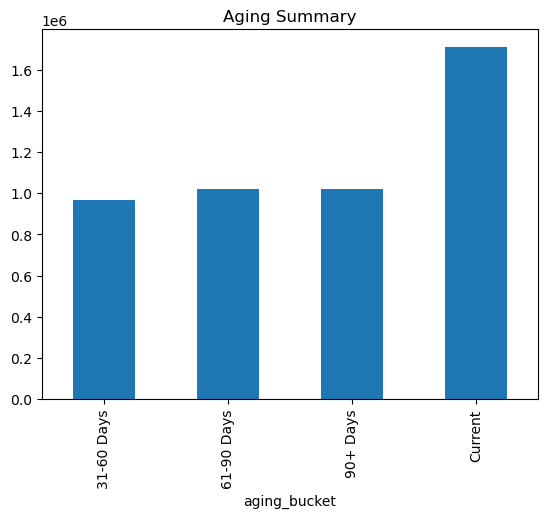

In [40]:
aging_report.drop(columns='Total').sum().plot(kind='bar',title='Aging Summary')
plt.show()

In [41]:
df_outstanding['weighted_value'] = (
    df_outstanding['days_overdue'] *
    df_outstanding['outstanding_bdt']
)

weighted_avg_customer = (
    df_outstanding.groupby('customer_name')[
        ['weighted_value', 'outstanding_bdt']
    ]
    .sum()
)

weighted_avg_customer['weighted_avg_days_overdue'] = (
    weighted_avg_customer['weighted_value'] /
    weighted_avg_customer['outstanding_bdt']
)

display(weighted_avg_customer.head())

C:\Users\Ligion\AppData\Local\Temp\ipykernel_11796\1594654162.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_outstanding['weighted_value'] = (


,weighted_value,outstanding_bdt,weighted_avg_days_overdue
customer_name,,,
Ayesha Textiles,23383900.0,371100.0,63.012396
Bilkis Garments,29050900.0,449200.0,64.672529
Farhan It Solutions,2481800.0,126200.0,19.665610
Fatima Enterprises,37886400.0,605100.0,62.611800
Hasan Electronics,6721700.0,133200.0,50.463213


In [42]:
display(df_outstanding.head())

,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city,outstanding_bdt,days_overdue,aging_bucket,weighted_value
0,INV-1072,Ayesha Textiles,2026-01-01 00:00:00,2026-03-02,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet,75000.0,69,61-90 Days,5175000.0
1,INV-1025,Ayesha Textiles,2026-04-07 00:00:00,2026-05-07,75000.0,0.0,Unpaid,NaT,Cosmetics,Sylhet,75000.0,3,Current,225000.0
2,INV-1052,Hasan Electronics,2026-02-08 00:00:00,2026-04-09,20000.0,0.0,Unpaid,NaT,Food,Rajshahi,20000.0,31,31-60 Days,620000.0
3,INV-1163,Fatima Enterprises,2026-02-20 00:00:00,2026-04-06,75000.0,26100.0,Partial,2026-04-28 00:00:00,Food,Chittagong,48900.0,34,31-60 Days,1662600.0
7,INV-1085,Tahmina Logistics,2026-02-26 00:00:00,2026-03-28,45000.0,21200.0,Partial,2026-04-10 00:00:00,Electronics,Dhaka,23800.0,43,31-60 Days,1023400.0
